<a href="https://colab.research.google.com/github/sumukhveeramalla/cs666student/blob/main/CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

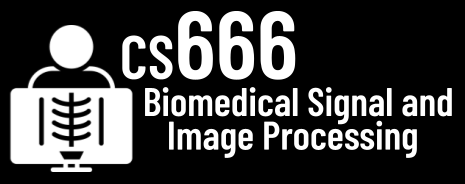
#Assignment 6

In [1]:
# NAME: Sumukh Veeramalla

In [2]:
# In this assignment, we will visualize and explore a CT scan!

In [3]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [4]:
# we are using pydicom, so lets install it!
!pip install pydicom

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 27.8 MB/s eta 0:00:00


**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [5]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [6]:
# TODO: YOUR CODE

!wget https://cs666.org/data/ct.zip

--2026-05-07 00:16:28--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip’

ct.zip              100%[===================>]   5.58M  --.-KB/s    in 0.06s   

2026-05-07 00:16:29 (89.2 MB/s) - ‘ct.zip’ saved [5847706/5847706]



In [7]:
# Then use the following snippet to extract the data.

In [8]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [9]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [10]:
# TODO: YOUR_ANSWER
# 220 slices.

In [11]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [12]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

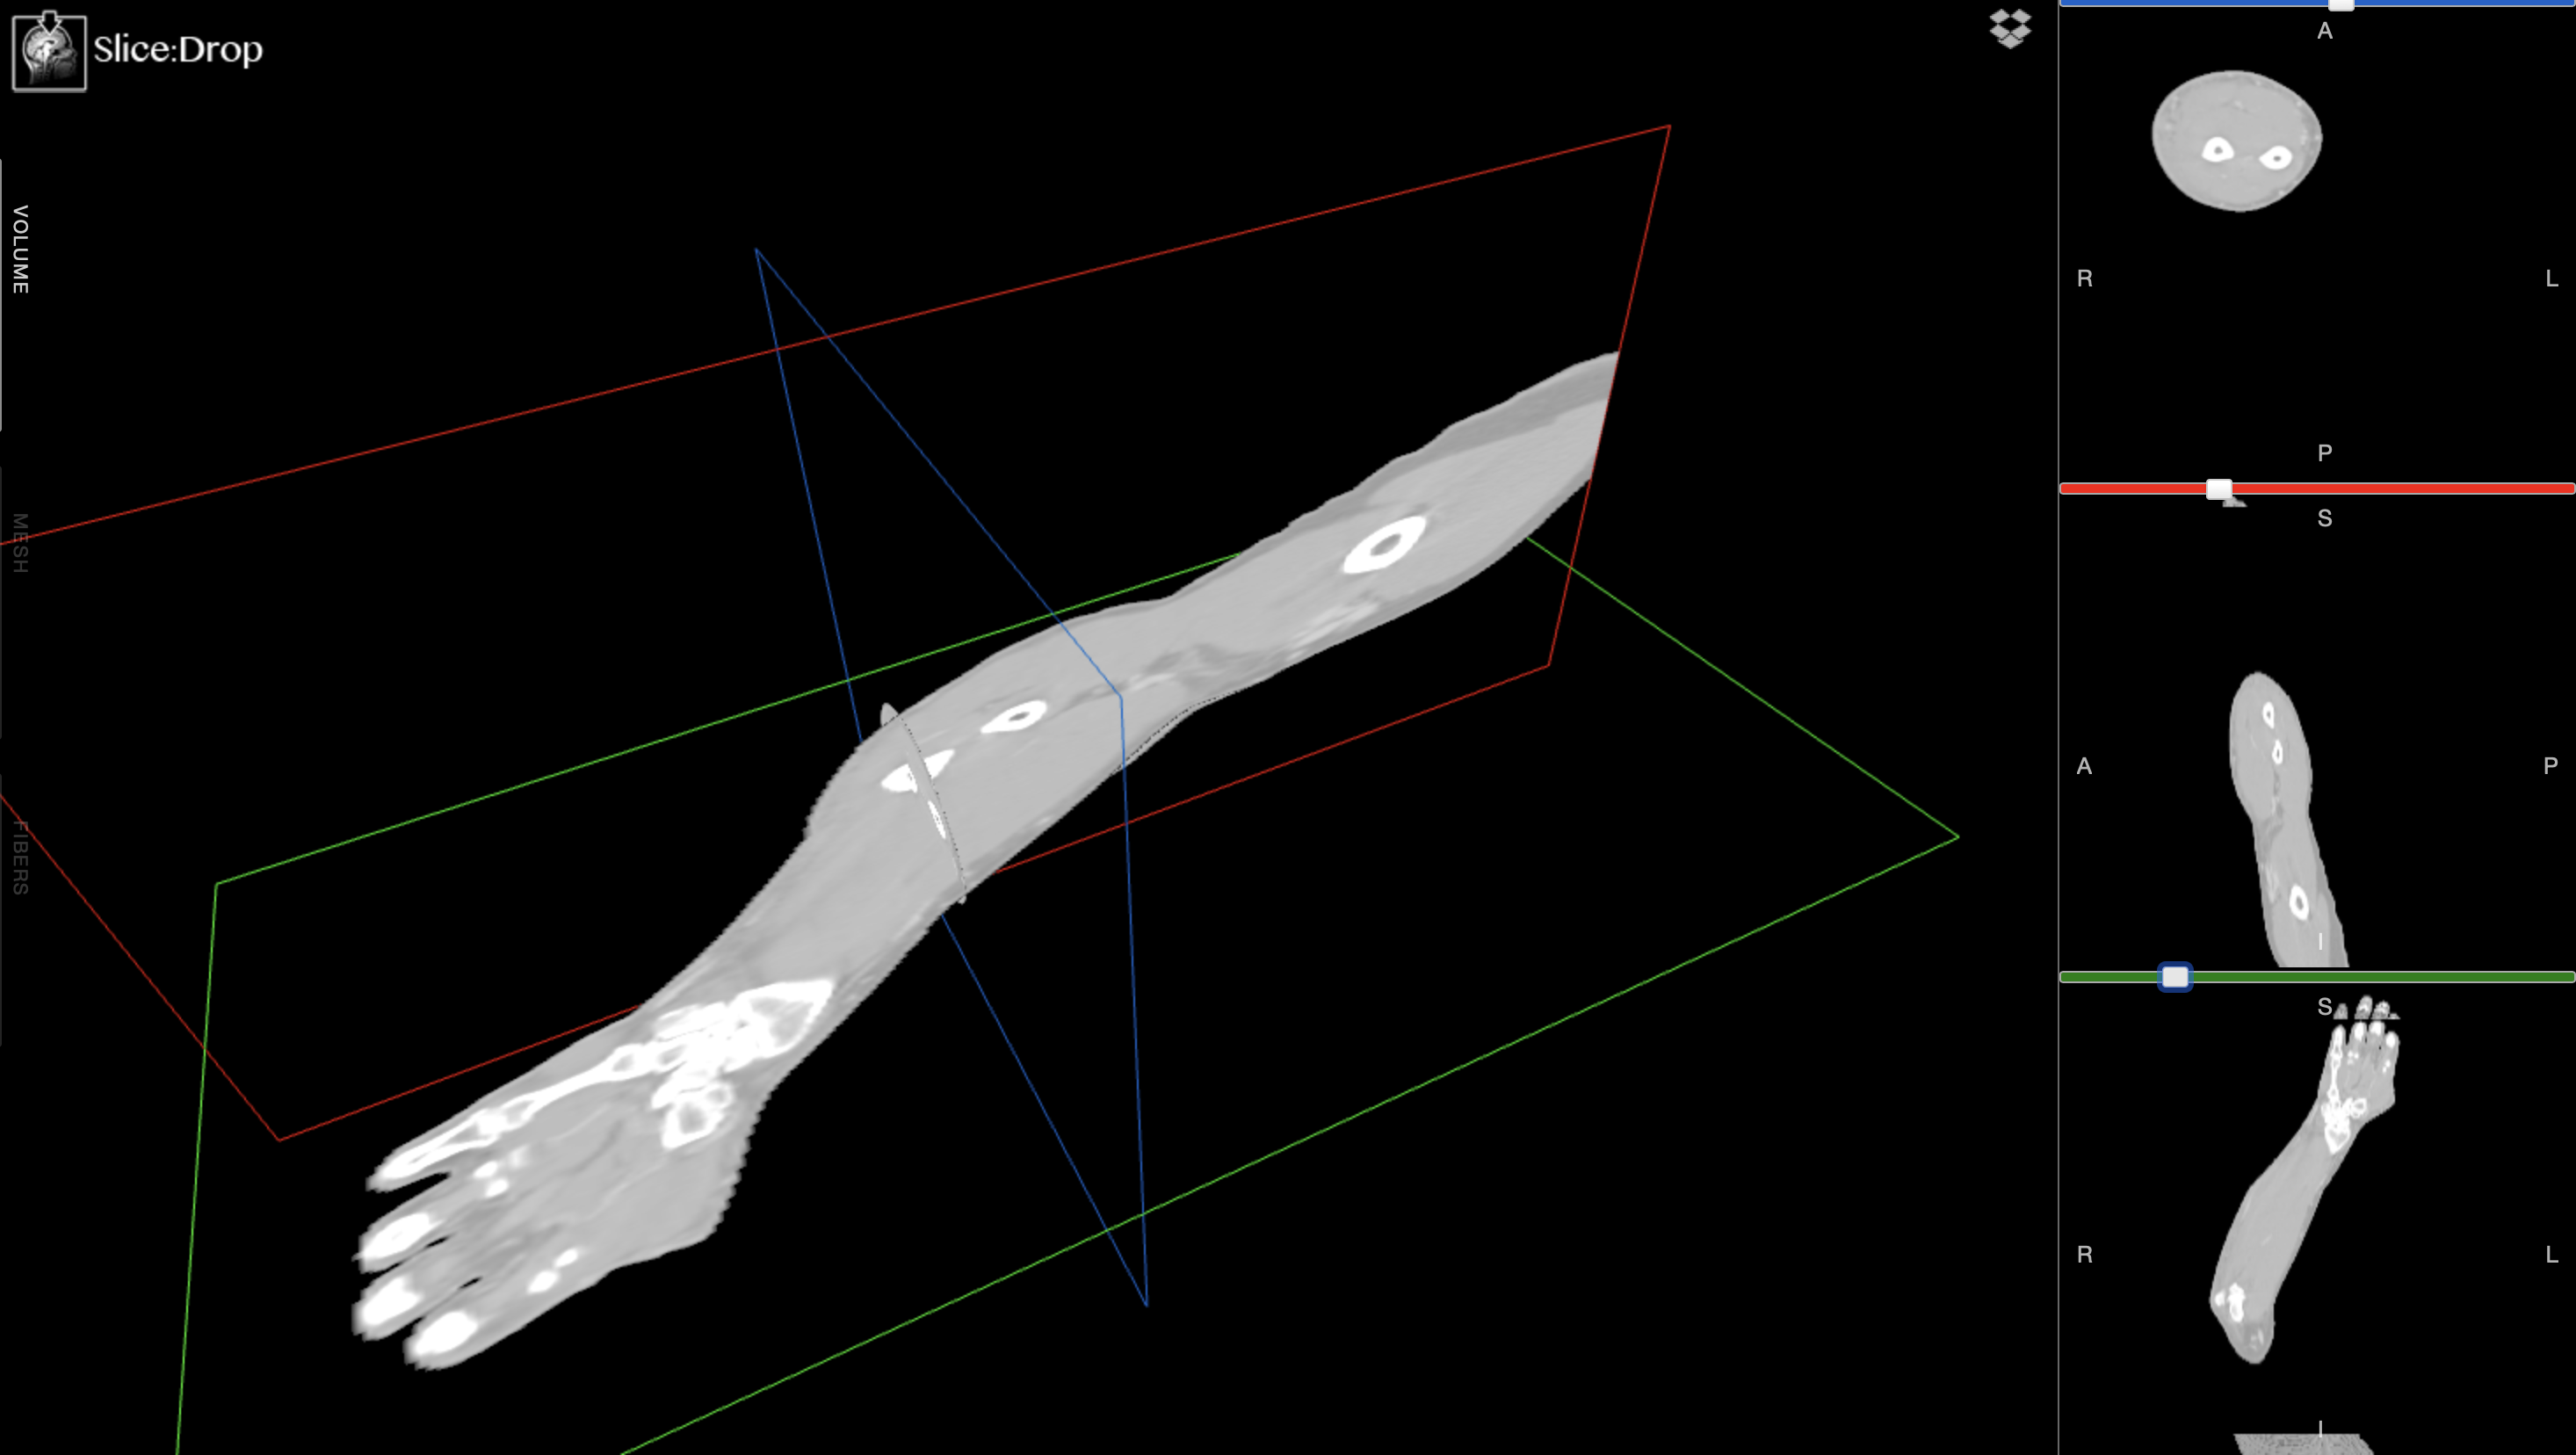

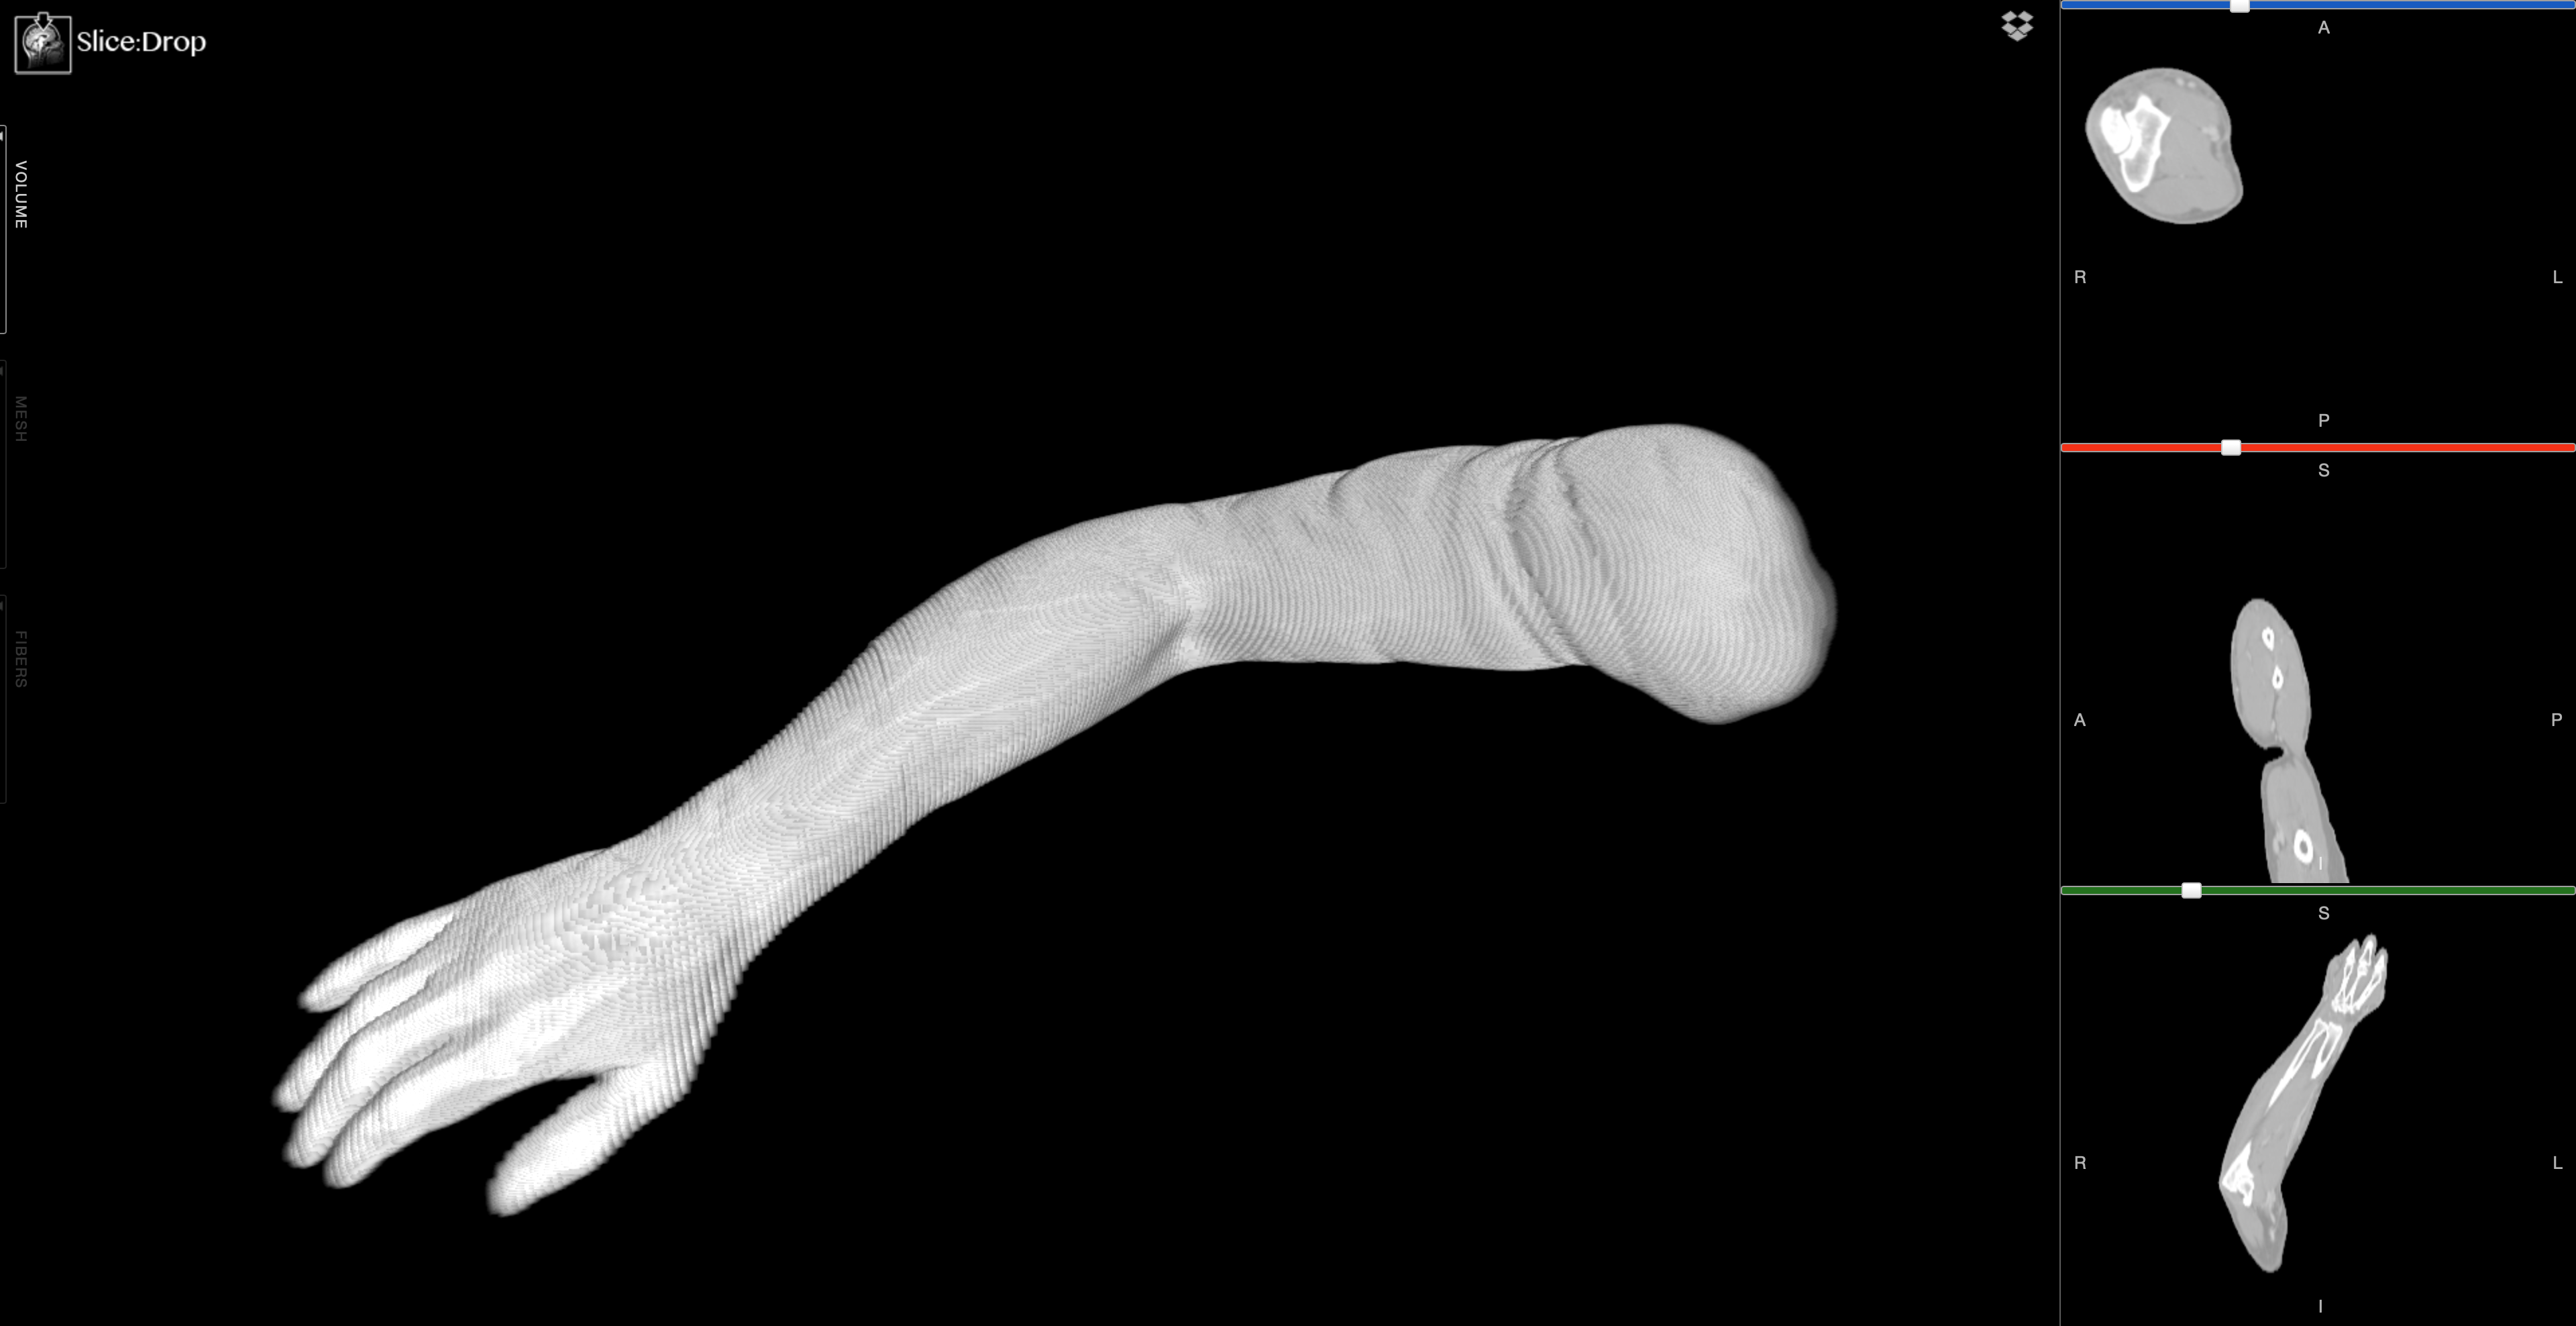

In [13]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [14]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

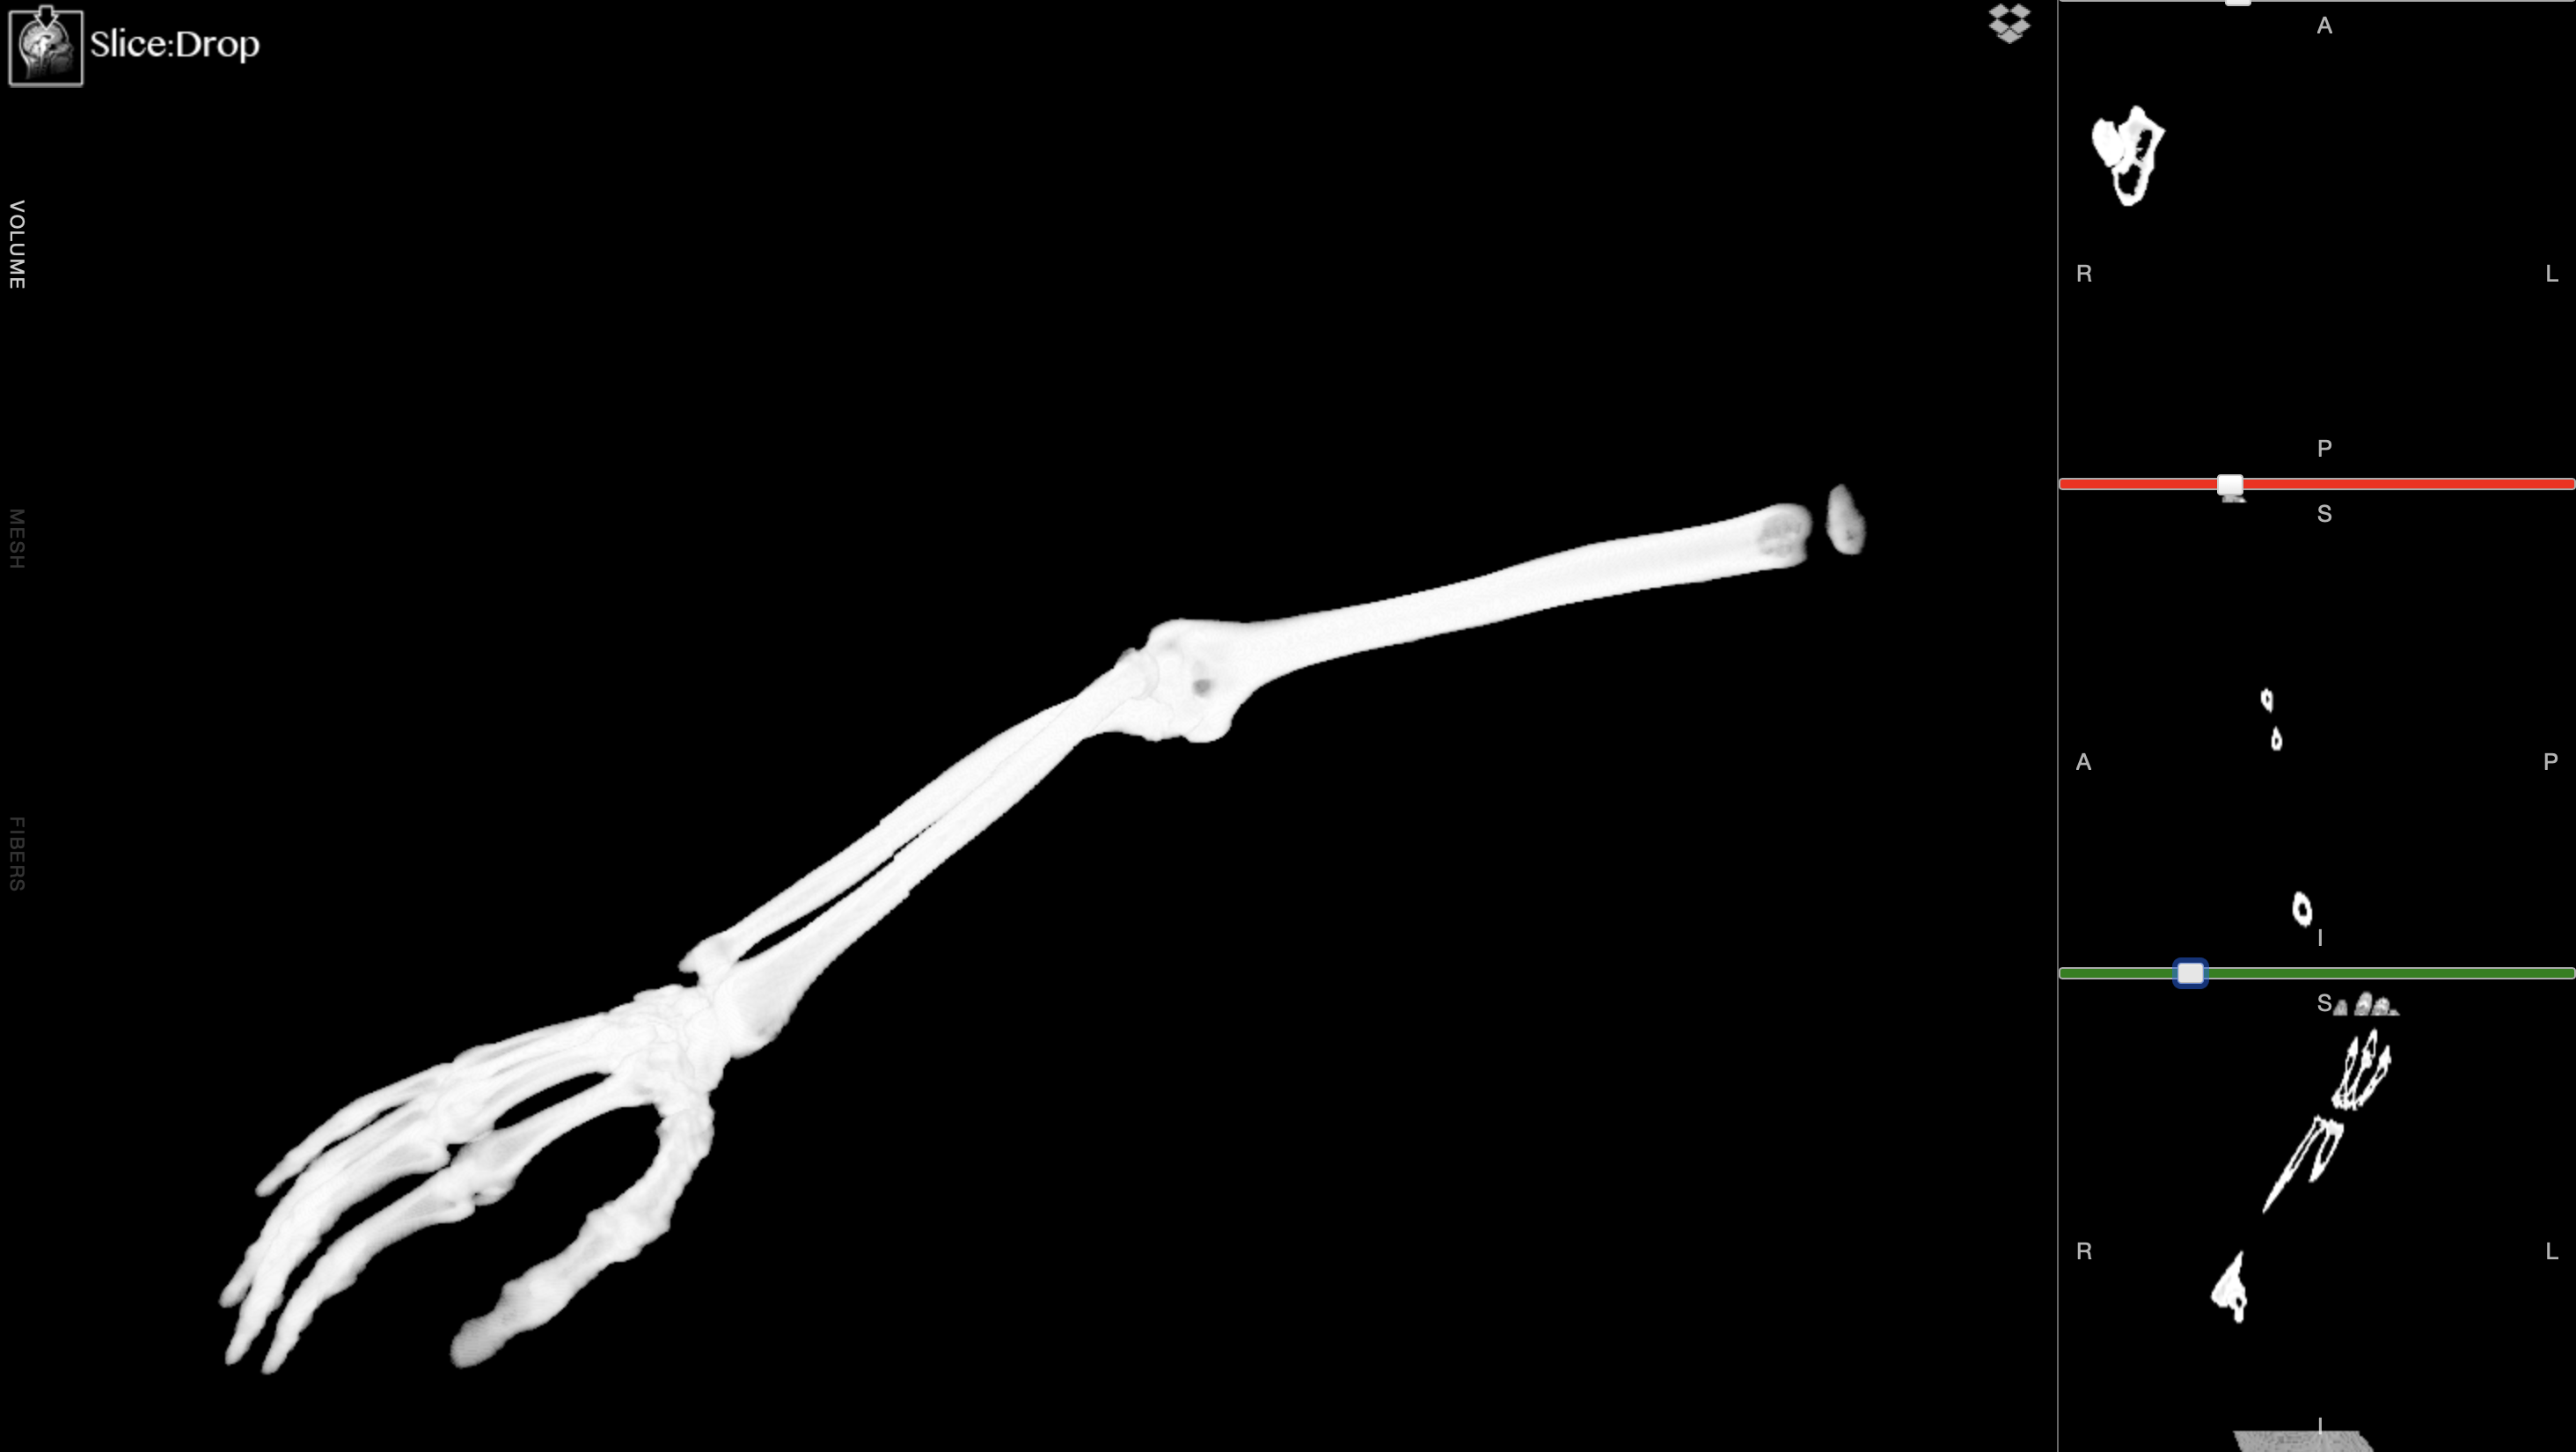

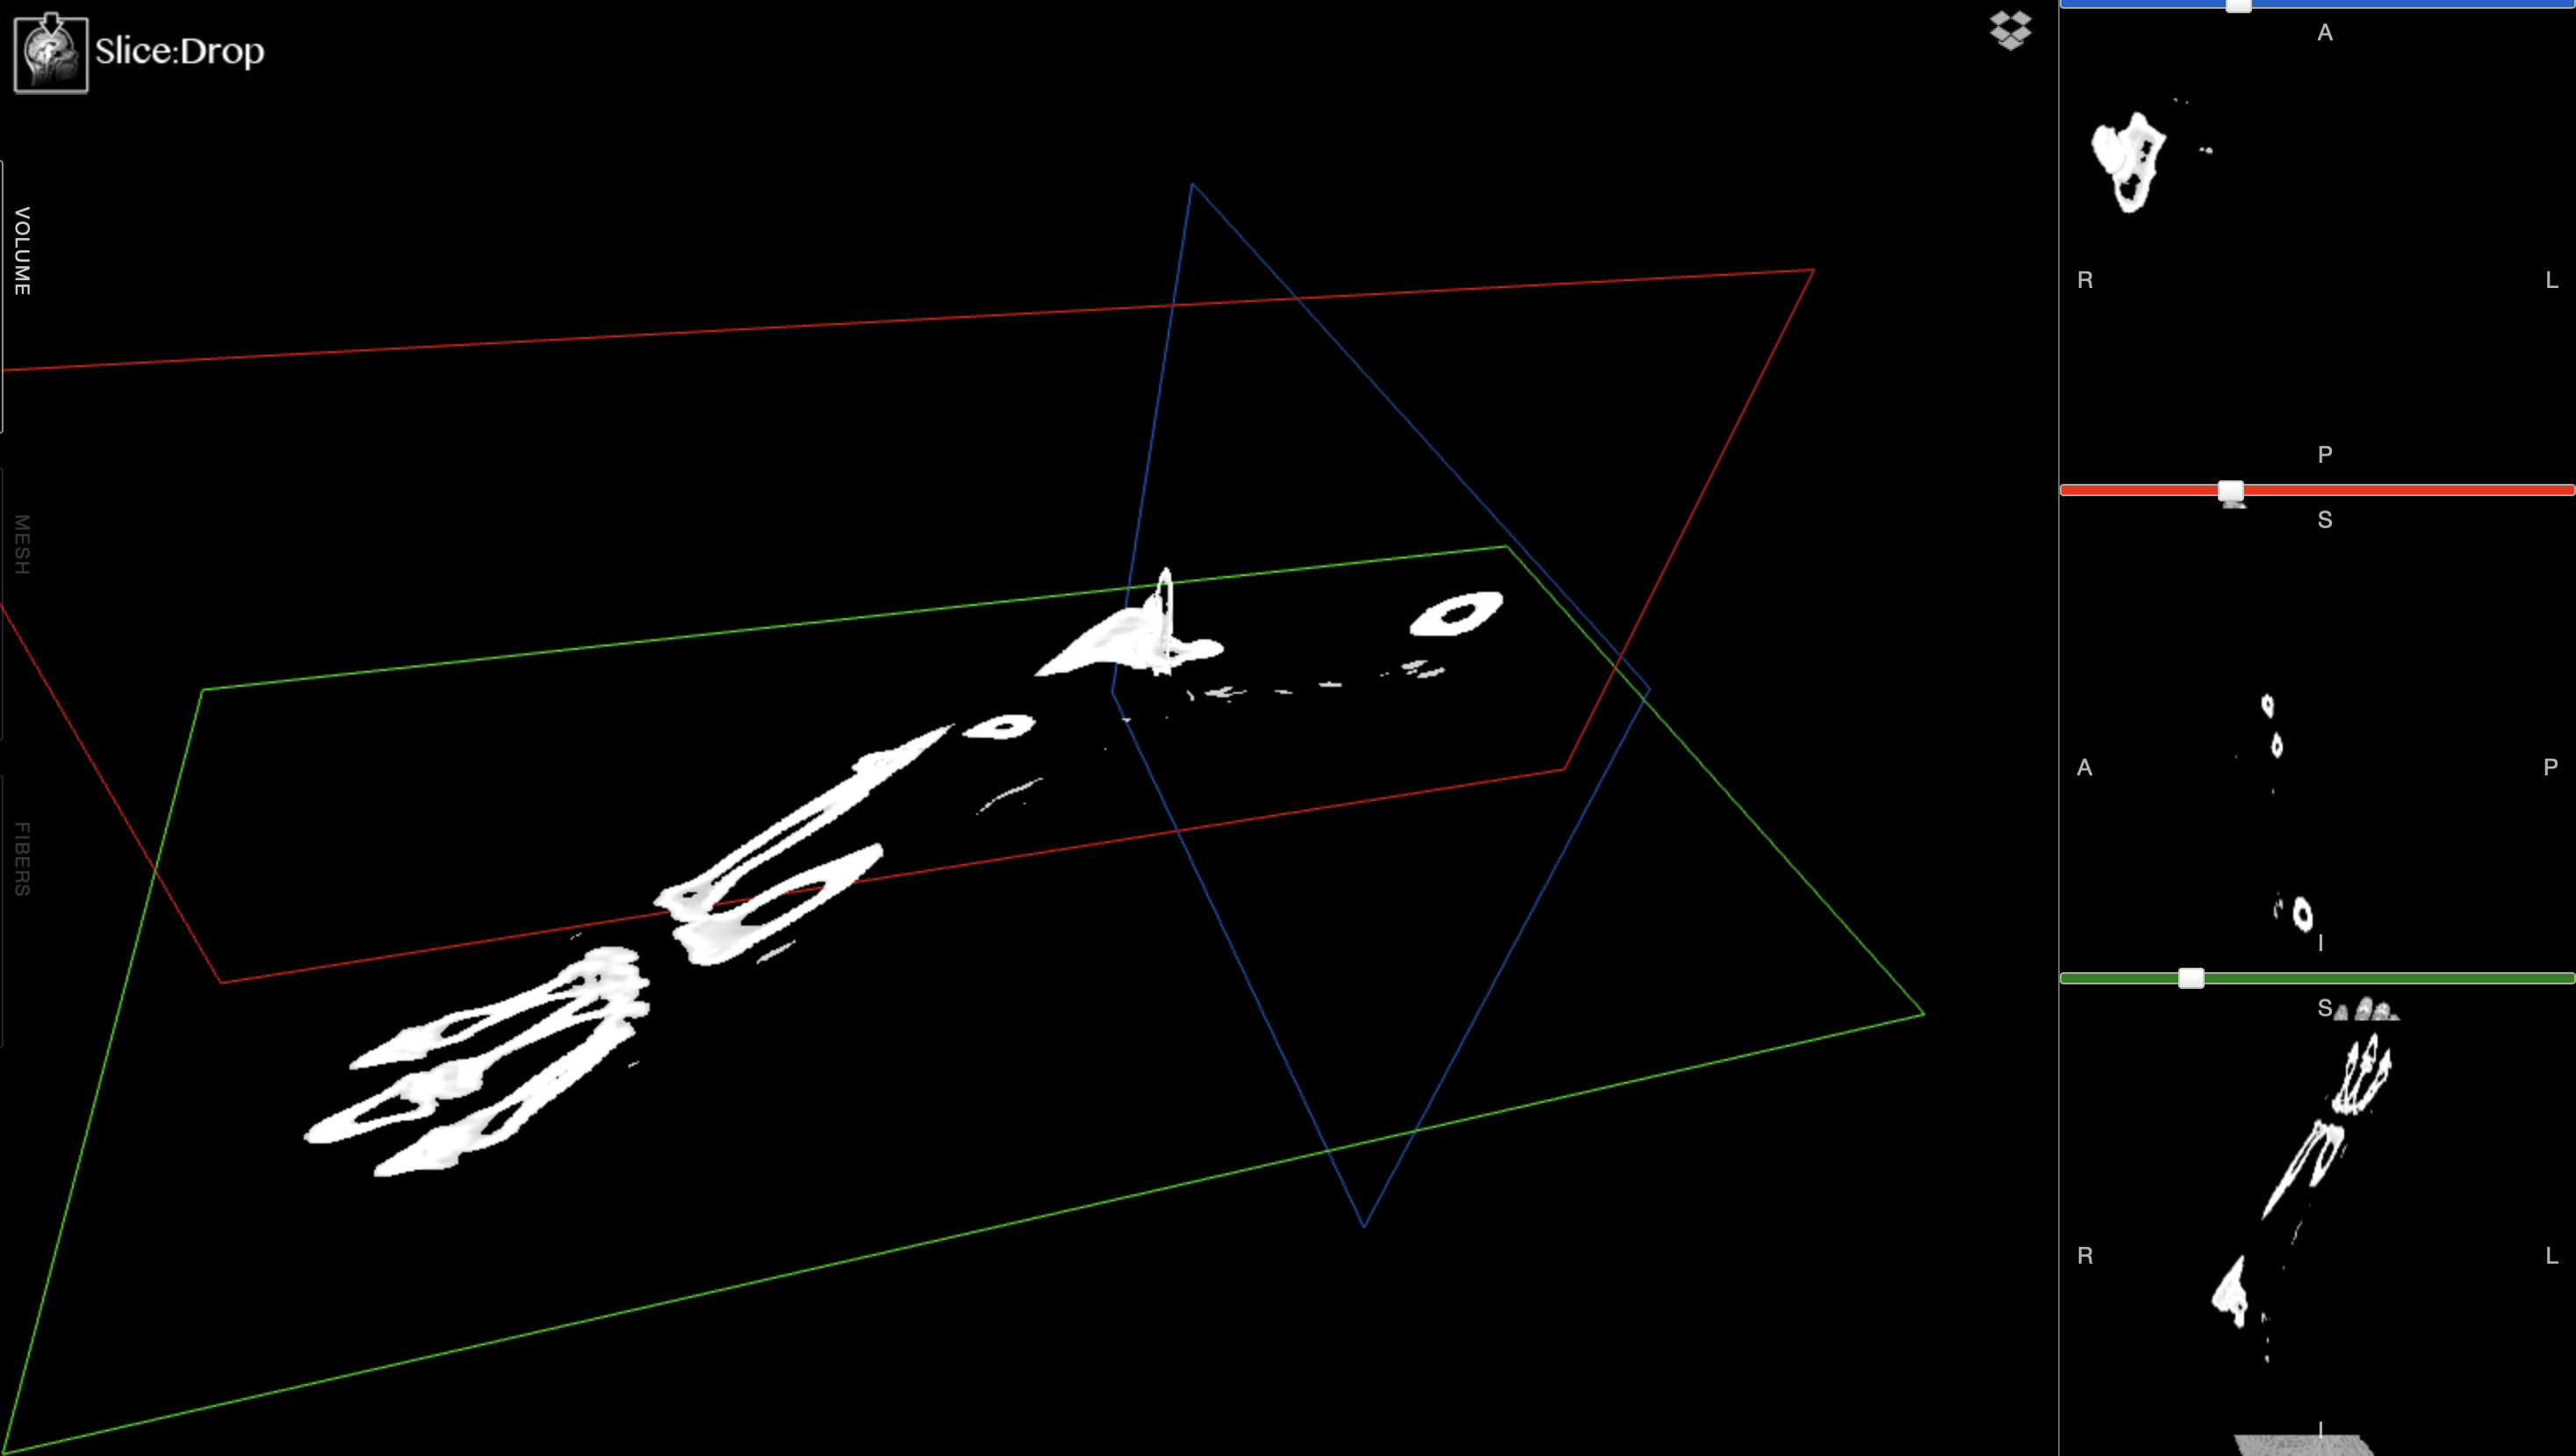

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [15]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [16]:
from pydicom import dcmread

In [17]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY

import os
import numpy as np

ct_dir = 'ct'
dicom_paths = [
    os.path.join(ct_dir, f)
    for f in os.listdir(ct_dir)
    if f.lower().endswith('.dcm')
]

slices = [dcmread(path) for path in dicom_paths]

if all(hasattr(ds, 'InstanceNumber') for ds in slices):
    slices.sort(key=lambda ds: int(ds.InstanceNumber))
elif all(hasattr(ds, 'ImagePositionPatient') for ds in slices):
    slices.sort(key=lambda ds: float(ds.ImagePositionPatient[2]))
else:
    slices.sort(key=lambda ds: os.path.basename(ds.filename))

volume = np.stack([ds.pixel_array for ds in slices], axis=0)

hu_slices = []
for ds in slices:
    pixels = ds.pixel_array.astype(np.float32)
    slope = float(getattr(ds, 'RescaleSlope', 1.0))
    intercept = float(getattr(ds, 'RescaleIntercept', 0.0))
    hu_slices.append(pixels * slope + intercept)

hu_volume = np.stack(hu_slices, axis=0)
print('HU volume shape:', hu_volume.shape)

HU volume shape: (220, 454, 512)


In [18]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

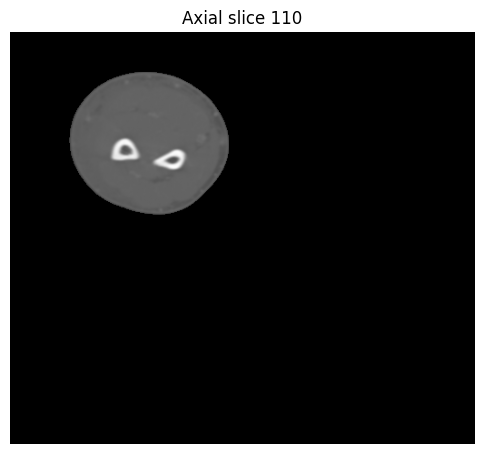

In [19]:
# TODO: YOUR CODE FOR AXIAL
axial_idx = hu_volume.shape[0] // 2

plt.figure(figsize=(6, 6))
plt.imshow(hu_volume[axial_idx], cmap='gray')
plt.title(f'Axial slice {axial_idx}')
plt.axis('off')
plt.show()

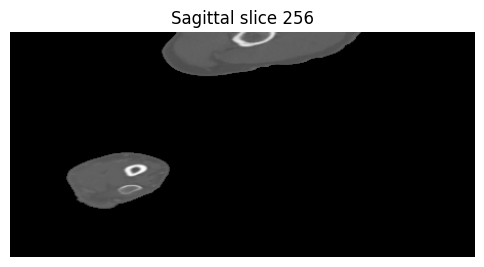

In [20]:
# TODO: YOUR CODE FOR SAGITTAL
sagittal_idx = hu_volume.shape[2] // 2

plt.figure(figsize=(6, 6))
plt.imshow(hu_volume[:, :, sagittal_idx], cmap='gray', origin='lower')
plt.title(f'Sagittal slice {sagittal_idx}')
plt.axis('off')
plt.show()

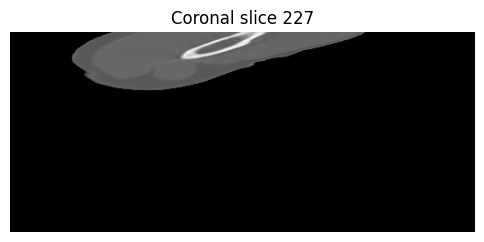

In [21]:
# TODO: YOUR CODE FOR CORONAL
coronal_idx = hu_volume.shape[1] // 2

plt.figure(figsize=(6, 6))
plt.imshow(hu_volume[:, coronal_idx, :], cmap='gray', origin='lower')
plt.title(f'Coronal slice {coronal_idx}')
plt.axis('off')
plt.show()

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [22]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [23]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

Window Center: 30.0
Window Width: 410.0
Rescale Intercept: -1024.0
Rescale Slope: 1.0


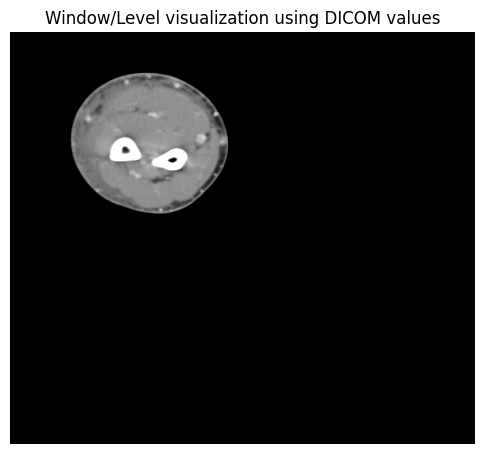

In [24]:
# TODO: YOUR CODE
def first_number(value, default=0.0):
    if value is None:
        return float(default)
    if isinstance(value, (list, tuple)):
        return float(value[0])
    try:
        return float(value)
    except TypeError:
        return float(value[0])

mid_ds = slices[len(slices) // 2]
window_center = first_number(getattr(mid_ds, 'WindowCenter', 40.0))
window_width = first_number(getattr(mid_ds, 'WindowWidth', 400.0))
rescale_intercept = first_number(getattr(mid_ds, 'RescaleIntercept', 0.0))
rescale_slope = first_number(getattr(mid_ds, 'RescaleSlope', 1.0), default=1.0)

print('Window Center:', window_center)
print('Window Width:', window_width)
print('Rescale Intercept:', rescale_intercept)
print('Rescale Slope:', rescale_slope)

mid_pixels = mid_ds.pixel_array.astype(np.float32) * rescale_slope + rescale_intercept
vmin = window_center - window_width / 2
vmax = window_center + window_width / 2

plt.figure(figsize=(6, 6))
plt.imshow(mid_pixels, cmap='gray', vmin=vmin, vmax=vmax)
plt.title('Window/Level visualization using DICOM values')
plt.axis('off')
plt.show()


In [25]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

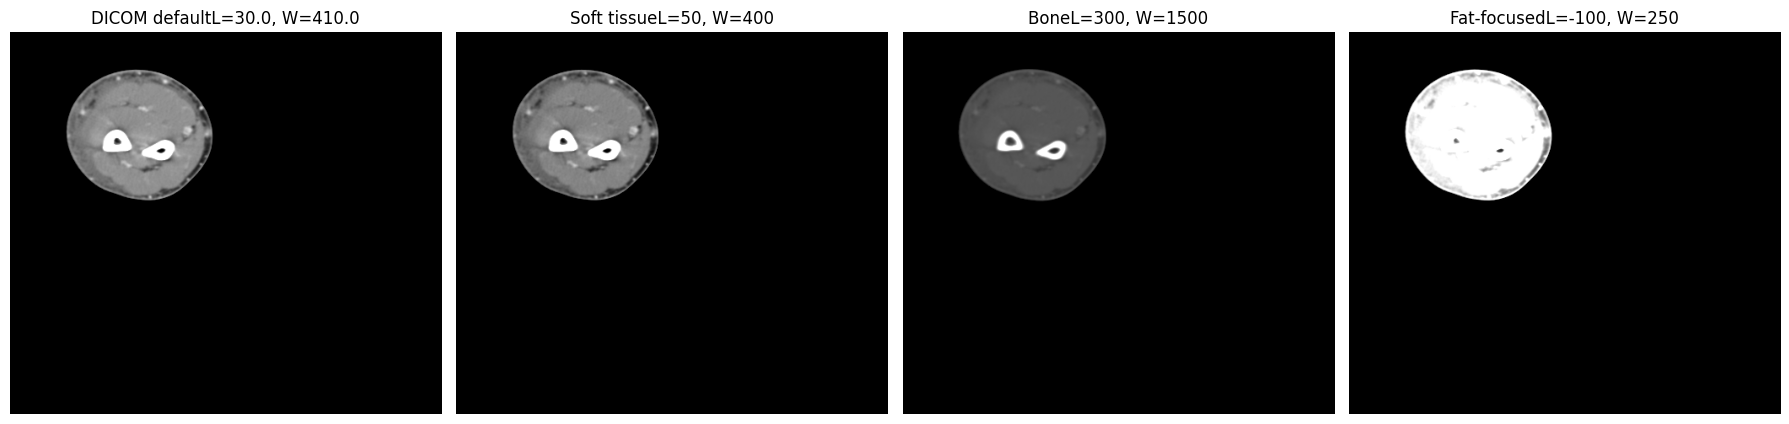

In [26]:
# TODO: YOUR CODE
window_presets = [
    ('DICOM default', window_center, window_width),
    ('Soft tissue', 50, 400),
    ('Bone', 300, 1500),
    ('Fat-focused', -100, 250),
]

fig, axes = plt.subplots(1, len(window_presets), figsize=(18, 5))

for ax, (label, level, window) in zip(axes, window_presets):
    vmin = level - window / 2
    vmax = level + window / 2
    ax.imshow(mid_pixels, cmap='gray', vmin=vmin, vmax=vmax)
    ax.set_title(f'{label}L={level}, W={window}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [27]:
# Which values make sense and why?

In [28]:
# TODO: YOUR ANSWER

#Here bone values make more sense here.
#Bone window values use a higher level and a wider width, so bright dense structures such as cortical bone remain visible without saturating too quickly.
#Soft-tissue windows use a lower level and narrower width, which improves contrast for muscle, fat, and other less-dense anatomy but here that is not that good.


**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [29]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

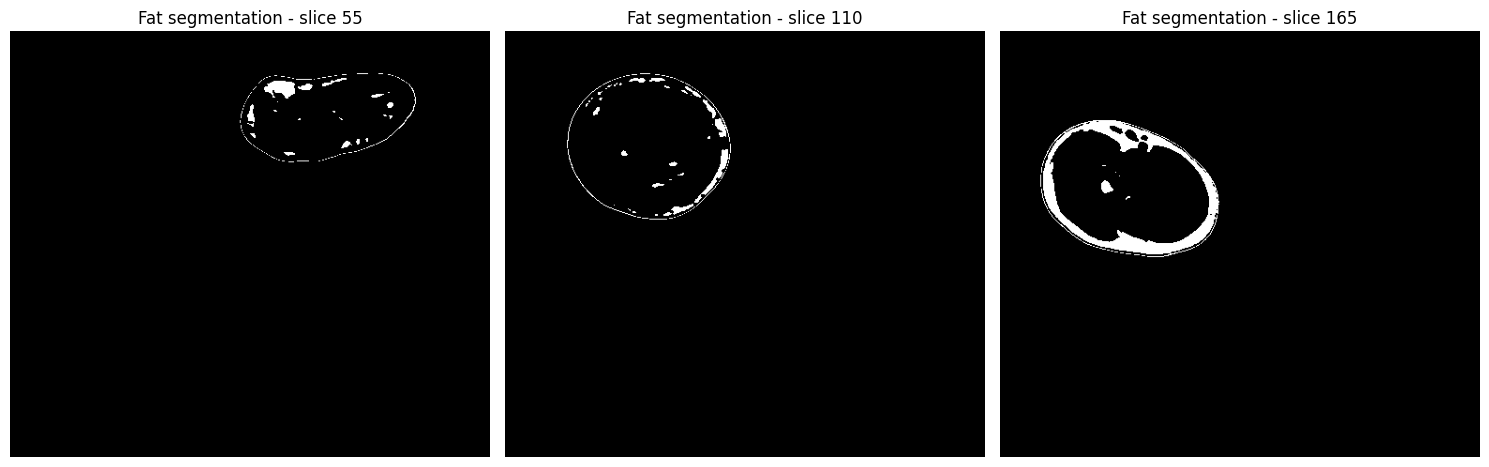

In [30]:
# TODO: YOUR CODE TO SEGMENT FAT

def show_mask_examples(mask, title):
    slice_ids = [hu_volume.shape[0] // 4, hu_volume.shape[0] // 2, 3 * hu_volume.shape[0] // 4]
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for ax, idx in zip(axes, slice_ids):
        ax.imshow(mask[idx], cmap='gray')
        ax.set_title(f'{title} - slice {idx}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

fat_mask = ((hu_volume >= -190) & (hu_volume <= -30)).astype(np.int16)
show_mask_examples(fat_mask, 'Fat segmentation')


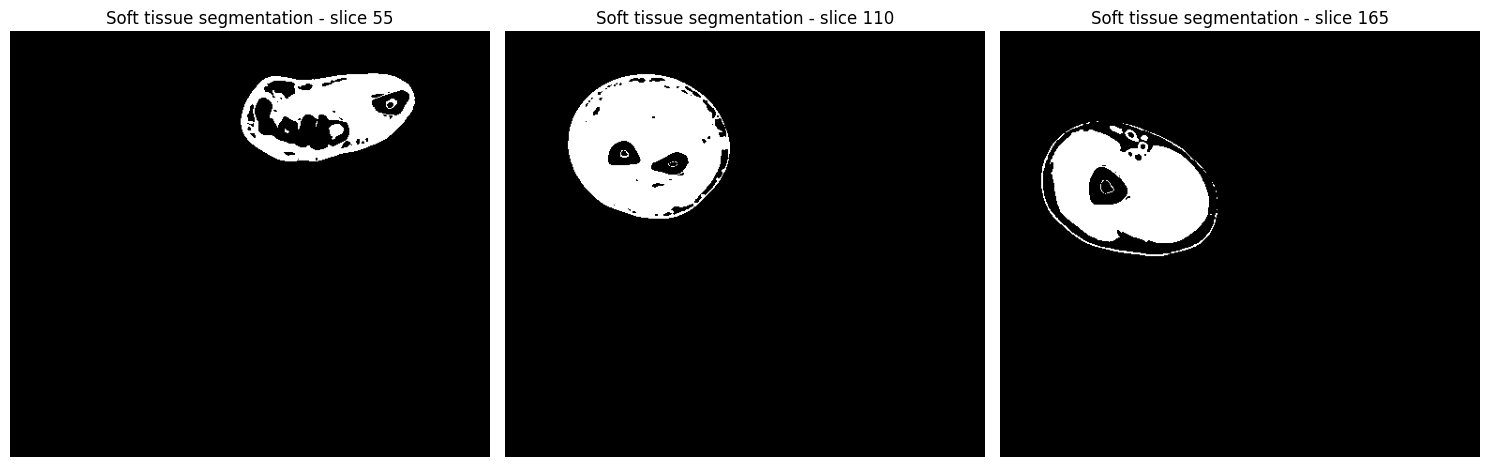

In [31]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE
soft_tissue_mask = ((hu_volume > -30) & (hu_volume <= 150)).astype(np.int16)
show_mask_examples(soft_tissue_mask, 'Soft tissue segmentation')


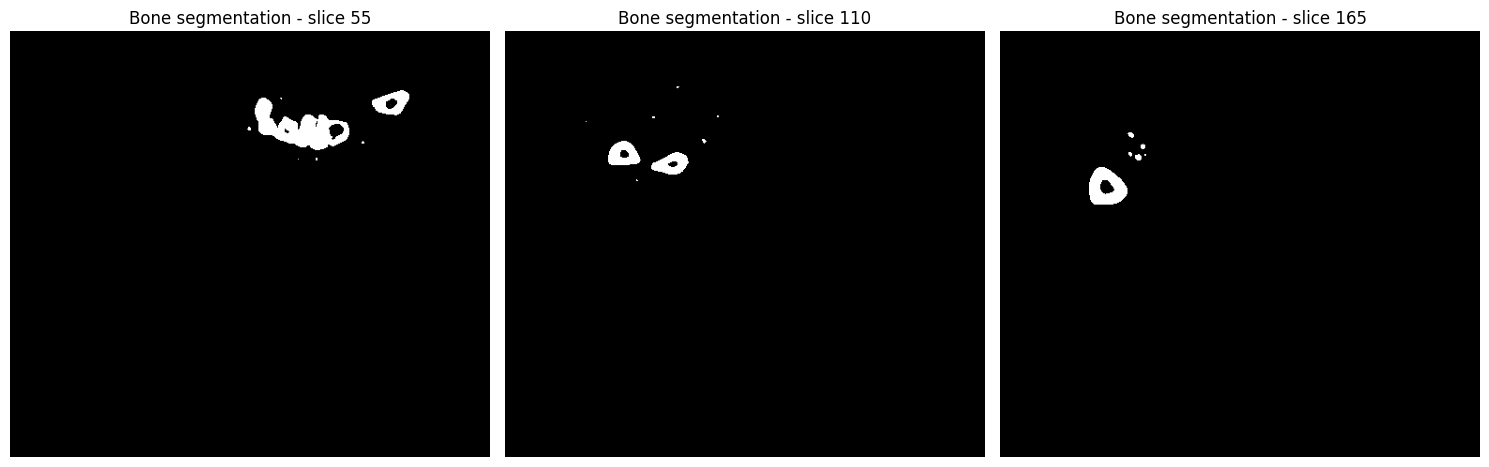

In [32]:
# TODO: YOUR CODE TO SEGMENT BONES
bone_mask = (hu_volume > 150).astype(np.int16)
show_mask_examples(bone_mask, 'Bone segmentation')

In [33]:
# Are the segmentations good?

In [34]:
# TODO: YOUR ANSWER

# Yes they are good and these threshold-based segmentations are useful for first approximations, but they are not perfect.
# Bone usually segments the best because dense cortical bone has much higher HU values than the surrounding tissue.
# Fat and soft tissue are more ambiguous because their HU ranges can overlap with skin, muscle, marrow, noise, and partial-volume voxels.

In [35]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""